In [1]:
# Importa a biblioteca necessária para interagir com o Google Drive no Google Colab
from google.colab import drive

# Monta o Google Drive no ambiente do Colab, permitindo acesso aos arquivos salvos no seu Drive
drive.mount('/content/drive')


Mounted at /content/drive


Total de relógios detectados: 7
Coordenadas dos relógios:  [[ 10  13 103 103]
 [180  12  98  98]
 [322  11 104 104]
 [172 166  91  91]
 [343 319  93  93]
 [189 324  99  99]
 [ 26 342  70  70]]

ROI 1


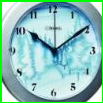

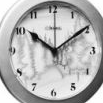


ROI 2


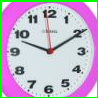

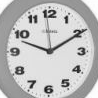


ROI 3


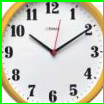

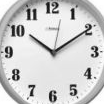


ROI 4


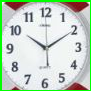

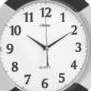


ROI 5


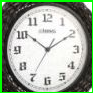

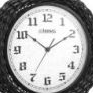


ROI 6


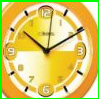

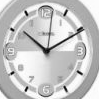


ROI 7


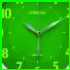

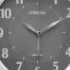


Imagem original com todos os relógios detectados:


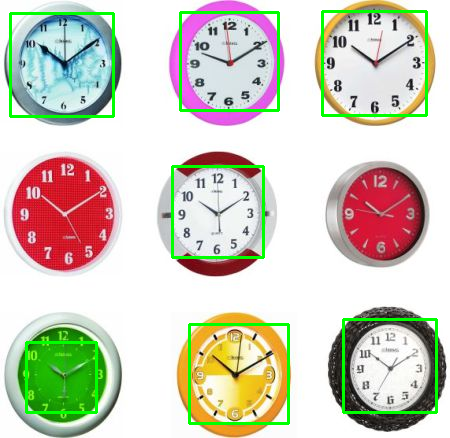

In [23]:
import cv2
from google.colab.patches import cv2_imshow

# Carrega o classificador de relógios
detec_clock = cv2.CascadeClassifier('/content/drive/MyDrive/Visão Computacional Guia Completo/Cascades/clocks.xml')

# Carrega a imagem
img = cv2.imread('/content/drive/MyDrive/Visão Computacional Guia Completo/Images/clock.jpg')

# Verifica se a imagem foi carregada corretamente
if img is None:
    print('Imagem não encontrada')
else:
    # Converte para tons de cinza
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Detecta relógios
    clock = detec_clock.detectMultiScale(gray, scaleFactor=1.03, minNeighbors=1)

    print(f"Total de relógios detectados: {len(clock)}")
    print("Coordenadas dos relógios: ", clock)

    # Para cada relógio detectado
    for i, (x, y, w, h) in enumerate(clock):
        # Desenha retângulo verde na imagem original
        cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 2)

        # Recorta a região do relógio em cinza e cor
        roi_gray = gray[y:y + h, x:x + w]
        roi_color = img[y:y + h, x:x + w]

        # Exibe a ROI colorida com número identificador
        print(f"\nROI {i + 1}")
        cv2_imshow(roi_color)
        cv2_imshow(roi_gray)

    # Exibe a imagem com todos os retângulos verdes
    print("\nImagem original com todos os relógios detectados:")
    cv2_imshow(img)
